In [ ]:
!pip install qiskit qiskit-aer qiskit-algorithms qiskit-machine-learning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.0 MB/s eta 0:00:00


In [ ]:
!pip install qiskit qiskit-aer
!pip install qiskit-algorithms
!pip install qiskit-machine-learning
!pip install pandas numpy matplotlib scikit-learn

print("All libraries installed!")

All libraries installed!


In [ ]:
import os, re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
warnings.filterwarnings('ignore')

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes, TwoLocal
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC, NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA, SLSQP

df = pd.read_csv('final_candidates_filtered.csv')
print(f"Total molecules    : {len(df)}")
print(f"QED avg            : {df.QED.mean():.3f}")
print(f"SA Score avg       : {df.sa_score.mean():.3f}")
print("DONE - Data Loaded!")

Total molecules    : 30
QED avg            : 0.821
SA Score avg       : 2.616
DONE - Data Loaded!


In [ ]:
# CELL 3 — Features, Labels + Augmentation

descriptor_cols = ['LogP', 'TPSA', 'HBD', 'HBA']

# ── Labels using median threshold ──
threshold           = df['enhanced_score'].median()
df['binding_label'] = (
    df['enhanced_score'] > threshold
).astype(int)

X_desc = df[descriptor_cols].values
y      = df['binding_label'].values

# ── Scale to [0, π] ──
scaler   = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X_desc)

print(f"Threshold        : {threshold:.3f}")
print(f"Original size    : {len(X_scaled)} molecules")
print(f"Good binders (1) : {y.sum()}")
print(f"Poor binders (0) : {(y==0).sum()}")

# ══════════════════════════════════════
#  DATA AUGMENTATION — Noise Injection
# ══════════════════════════════════════

np.random.seed(42)  # for reproducibility

def augment_data(X, y, times=9):
    """
    Creates new molecules by adding
    tiny random noise to existing ones
    30 molecules x 10 = 300 molecules
    """
    X_all = [X]  # start with original
    y_all = [y]

    for i in range(times):
        # Add tiny random noise
        # 0.05 = small enough to be realistic
        noise   = np.random.normal(
            0, 0.05, X.shape
        )
        X_noisy = X + noise

        # Keep values in valid range [0, π]
        X_noisy = np.clip(X_noisy, 0, np.pi)

        X_all.append(X_noisy)
        y_all.append(y)

    return np.vstack(X_all), np.hstack(y_all)

# ── Apply augmentation ──
X_aug, y_aug = augment_data(X_scaled, y, times=9)

# ── Use augmented data ──
X_scaled = X_aug
y        = y_aug

print(f"\nAfter Augmentation:")
print(f"New size         : {len(X_scaled)} molecules")
print(f"Good binders (1) : {y.sum()}")
print(f"Poor binders (0) : {(y==0).sum()}")
print("\nDONE - Features + Augmentation Ready!")

Threshold        : 0.776
Original size    : 30 molecules
Good binders (1) : 15
Poor binders (0) : 15

After Augmentation:
New size         : 300 molecules
Good binders (1) : 150
Poor binders (0) : 150

DONE - Features + Augmentation Ready!


In [ ]:
feature_map = ZZFeatureMap(
    feature_dimension=4,
    reps=2,
    entanglement='linear'
)
print(f"Qubits    : {feature_map.num_qubits}")
print(f"Params    : {feature_map.num_parameters}")
print("DONE - ZZFeatureMap Created!")

Qubits    : 4
Params    : 4
DONE - ZZFeatureMap Created!


In [ ]:
feature_map = ZZFeatureMap(
    feature_dimension=4,
    reps=2,
    entanglement='linear'
)
print(f"Qubits    : {feature_map.num_qubits}")
print(f"Params    : {feature_map.num_parameters}")
print("DONE - ZZFeatureMap Created!")

Qubits    : 4
Params    : 4
DONE - ZZFeatureMap Created!


In [ ]:
# CELL 5 — Train QSVM

print("Training QSVM... please wait 5-10 mins")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

sampler        = Sampler()
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)
qsvc           = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train, y_train)

qsvm_predictions      = qsvc.predict(X_scaled)
qsvm_test_predictions = qsvc.predict(X_test)
train_acc             = accuracy_score(y_train, qsvc.predict(X_train))
test_acc              = accuracy_score(y_test, qsvm_test_predictions)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(classification_report(y_test, qsvm_test_predictions,
      target_names=['Poor Binder','Good Binder']))

# ── Predict on ORIGINAL 30 molecules only ──
# X_scaled[:30] = first 30 = original molecules
qsvm_orig_predictions = qsvc.predict(X_scaled[:30])

df_qsvm = df[['smiles','source','QED','sa_score',
              'enhanced_score','pred_affinity','admet_score']].copy()
df_qsvm['true_label']      = y[:30]
df_qsvm['qsvm_prediction'] = qsvm_orig_predictions
df_qsvm['correct']         = (y[:30] == qsvm_orig_predictions)
df_qsvm.to_csv('qsvm_results.csv', index=False)
print("SAVED qsvm_results.csv")
print("DONE - QSVM Complete!")

Training QSVM... please wait 5-10 mins
Train Accuracy : 0.9708
Test Accuracy  : 0.9667
              precision    recall  f1-score   support

 Poor Binder       0.94      1.00      0.97        33
 Good Binder       1.00      0.93      0.96        27

    accuracy                           0.97        60
   macro avg       0.97      0.96      0.97        60
weighted avg       0.97      0.97      0.97        60

SAVED qsvm_results.csv
DONE - QSVM Complete!


In [ ]:
# CELL 3 — Features & Labels

descriptor_cols = ['LogP', 'TPSA', 'HBD', 'HBA']

# Use median as threshold
# This always gives 2 classes no matter what
threshold = df['enhanced_score'].median()

df['binding_label'] = (
    df['enhanced_score'] > threshold
).astype(int)

X_desc   = df[descriptor_cols].values
y        = df['binding_label'].values

scaler   = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X_desc)

print(f"Threshold used   : {threshold:.3f}")
print(f"Good binders (1) : {df['binding_label'].sum()}")
print(f"Poor binders (0) : {(df['binding_label']==0).sum()}")
print(f"Feature shape    : {X_scaled.shape}")
print(f"Labels           : {y.tolist()}")
print("DONE - Features Ready!")

Threshold used   : 0.776
Good binders (1) : 15
Poor binders (0) : 15
Feature shape    : (30, 4)
Labels           : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
DONE - Features Ready!


In [ ]:
print("Training QSVM... please wait 5-10 mins")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

sampler        = Sampler()
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)
qsvc           = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train, y_train)

qsvm_predictions      = qsvc.predict(X_scaled)
qsvm_test_predictions = qsvc.predict(X_test)
train_acc             = accuracy_score(y_train, qsvc.predict(X_train))
test_acc              = accuracy_score(y_test, qsvm_test_predictions)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(classification_report(y_test, qsvm_test_predictions,
      target_names=['Poor Binder','Good Binder']))

df_qsvm = df[['smiles','source','QED','sa_score',
              'enhanced_score','pred_affinity','admet_score']].copy()
df_qsvm['true_label']      = y
df_qsvm['qsvm_prediction'] = qsvm_predictions
df_qsvm['correct']         = (y == qsvm_predictions)
df_qsvm.to_csv('qsvm_results.csv', index=False)
print("SAVED qsvm_results.csv")
print("DONE - QSVM Complete!")

Training QSVM... please wait 5-10 mins
Train Accuracy : 1.0000
Test Accuracy  : 0.3333
              precision    recall  f1-score   support

 Poor Binder       0.00      0.00      0.00         4
 Good Binder       0.33      1.00      0.50         2

    accuracy                           0.33         6
   macro avg       0.17      0.50      0.25         6
weighted avg       0.11      0.33      0.17         6

SAVED qsvm_results.csv
DONE - QSVM Complete!


In [ ]:
print("Training QNN... please wait 10-15 mins")

num_qubits      = 4
feature_map_qnn = ZZFeatureMap(num_qubits, reps=1)
ansatz          = RealAmplitudes(num_qubits, reps=1, entanglement='linear')
qnn_circuit     = feature_map_qnn.compose(ansatz)

sampler_qnn = SamplerQNN(
    circuit=qnn_circuit,
    input_params=feature_map_qnn.parameters,
    weight_params=ansatz.parameters,
    interpret=lambda x: x % 2,
    output_shape=2
)

losses = []
def callback(weights, obj_func_eval):
    losses.append(obj_func_eval)
    print(f"Loss: {obj_func_eval:.4f}", end='\r')

optimizer      = COBYLA(maxiter=150)
qnn_classifier = NeuralNetworkClassifier(
    neural_network=sampler_qnn,
    optimizer=optimizer,
    callback=callback
)
qnn_classifier.fit(X_scaled, y)
qnn_predictions = qnn_classifier.predict(X_scaled)
qnn_acc         = accuracy_score(y, qnn_predictions)

print(f"\nQNN Accuracy : {qnn_acc:.4f}")
df_qsvm['qnn_prediction'] = qnn_predictions
df_qsvm['qsvm_qnn_agree'] = (qsvm_predictions == qnn_predictions)
df_qsvm.to_csv('qsvm_results.csv', index=False)
print("SAVED qsvm_results.csv updated")
print("DONE - QNN Complete!")

Training QNN... please wait 10-15 mins

QNN Accuracy : 0.6467


ValueError: Length of values (300) does not match length of index (30)

In [ ]:
# CELL 6 — Train QNN (Improved)

print("Training QNN... please wait 15-20 mins")

num_qubits      = 4

# ── More powerful circuit ──
# reps=2 instead of 1 = deeper circuit
feature_map_qnn = ZZFeatureMap(num_qubits, reps=2)
ansatz          = RealAmplitudes(
    num_qubits,
    reps=3,                # increased from 1 to 3
    entanglement='full'    # changed from linear to full
)
qnn_circuit = feature_map_qnn.compose(ansatz)

sampler_qnn = SamplerQNN(
    circuit=qnn_circuit,
    input_params=feature_map_qnn.parameters,
    weight_params=ansatz.parameters,
    interpret=lambda x: x % 2,
    output_shape=2
)

losses = []
def callback(weights, obj_func_eval):
    losses.append(obj_func_eval)
    print(f"Loss: {obj_func_eval:.4f}", end='\r')

# ── More iterations ──
# 300 instead of 150
optimizer      = COBYLA(maxiter=300)
qnn_classifier = NeuralNetworkClassifier(
    neural_network=sampler_qnn,
    optimizer=optimizer,
    callback=callback
)
qnn_classifier.fit(X_scaled, y)

# ── Predict on original 30 only ──
qnn_all_predictions  = qnn_classifier.predict(X_scaled)
qnn_orig_predictions = qnn_classifier.predict(X_scaled[:30])
qnn_acc              = accuracy_score(y, qnn_all_predictions)

print(f"\nQNN Accuracy : {qnn_acc:.4f}")

df_qsvm['qnn_prediction'] = qnn_orig_predictions
df_qsvm['qsvm_qnn_agree'] = (
    df_qsvm['qsvm_prediction'] == qnn_orig_predictions
)
df_qsvm.to_csv('qsvm_results.csv', index=False)
print("SAVED qsvm_results.csv updated")
print("DONE - QNN Complete!")

Training QNN... please wait 15-20 mins

QNN Accuracy : 0.8533
SAVED qsvm_results.csv updated
DONE - QNN Complete!


In [ ]:
# CELL 7 — Extract Top 5 Fragments

print("="*45)
print("STEP 7 - Extracting Top 5 Fragments")
print("="*45)

# ── Top 5 molecules by enhanced_score ──
df_top5 = df.nlargest(5, 'enhanced_score').reset_index(drop=True)

print("Top 5 molecules selected:")
for i, row in df_top5.iterrows():
    print(f"  {i+1}. score={row['enhanced_score']:.3f}"
          f"  {row['smiles'][:45]}...")

# ── Extract fragments from SMILES ──
def extract_fragments(smiles):
    fragments    = []
    ring_pattern = r'[a-z]\d[^()]*\d'
    rings        = re.findall(ring_pattern, smiles)
    fragments.extend(rings[:2])
    chain_parts  = smiles.split('C(=O)')
    for part in chain_parts:
        part = part.strip('()').strip()
        if len(part) > 3:
            fragments.append(part[:20])
    return fragments[:3]

all_fragments = []
for idx, row in df_top5.iterrows():
    frags = extract_fragments(row['smiles'])
    for j, frag in enumerate(frags):
        all_fragments.append({
            'fragment_id':   f"frag_{idx+1}_{j+1}",
            'parent_smiles': row['smiles'],
            'fragment':      frag,
            'parent_score':  row['enhanced_score']
        })

df_fragments = pd.DataFrame(all_fragments)
df_fragments = df_fragments.drop_duplicates(
    subset='fragment'
).head(5).reset_index(drop=True)

print(f"\nTop 5 fragments extracted:")
print(df_fragments[[
    'fragment_id',
    'fragment',
    'parent_score'
]])
print("\nDONE - Fragments Extracted!")

STEP 7 - Extracting Top 5 Fragments
Top 5 molecules selected:
  1. score=0.809  CN(C(=O)c1ccc(S(N)(=O)=O)cc1)C1CCCCC1...
  2. score=0.792  Cc1ccc(CNC(=O)C2CCCC2CN)nc1...
  3. score=0.792  CCc1ccc(S(=O)(=O)N2CCCC(CN)C2)c(C)c1...
  4. score=0.788  CC(=O)N[C@H](C)C(=O)CCC(=O)Nc1ccc(C)cc1...
  5. score=0.787  CC(C)C(NC(=O)C1CCN1)c1ccccc1...

Top 5 fragments extracted:
  fragment_id              fragment  parent_score
0    frag_1_1  c1ccc(S(N)(=O)=O)cc1      0.808936
1    frag_2_1             Cc1ccc(CN      0.792092
2    frag_2_2         C2CCCC2CN)nc1      0.792092
3    frag_3_1  CCc1ccc(S(=O)(=O)N2C      0.791611
4    frag_4_1              N[C@H](C      0.788020

DONE - Fragments Extracted!


In [ ]:
# CELL 8 — Run VQE on 5 Fragments

print("="*45)
print("STEP 8 - Running VQE on 5 Fragments")
print("Longest step ~30-60 mins...")
print("="*45)

from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import SLSQP

vqe_results_list = []

for idx, frag_row in df_fragments.iterrows():
    frag_id   = frag_row['fragment_id']
    frag_str  = frag_row['fragment']
    parent_sc = frag_row['parent_score']

    print(f"\nFragment {idx+1}/5 : {frag_id}")
    print(f"  Fragment     : {frag_str}")

    try:
        num_atoms      = len([c for c in frag_str
                              if c.isupper()])
        num_qubits_vqe = min(max(2, num_atoms // 3), 4)

        # ── Build Hamiltonian ──
        coeffs = [
            -0.5 - 0.1 * num_atoms,
             0.2 * parent_sc,
            -0.3,
             0.1 * num_atoms
        ]
        pauli_strings = ['ZZ', 'XX', 'YY', 'ZI']
        pauli_list    = []
        for coeff, pauli in zip(coeffs, pauli_strings):
            padded = pauli.ljust(
                num_qubits_vqe, 'I'
            )[:num_qubits_vqe]
            pauli_list.append((padded, coeff))

        hamiltonian = SparsePauliOp.from_list(pauli_list)
        print(f"  Qubits       : {num_qubits_vqe}")

        # ── Classical reference ──
        numpy_solver     = NumPyMinimumEigensolver()
        classical_result = numpy_solver.compute_minimum_eigenvalue(
            hamiltonian
        )
        classical_energy = float(
            classical_result.eigenvalue.real
        )

        # ── VQE ──
        ansatz_vqe = TwoLocal(
            num_qubits_vqe,
            rotation_blocks=['ry', 'rz'],
            entanglement_blocks='cz',
            reps=2
        )
        optimizer_vqe = SLSQP(maxiter=200)
        estimator_vqe = Estimator()

        vqe        = VQE(
            estimator=estimator_vqe,
            ansatz=ansatz_vqe,
            optimizer=optimizer_vqe
        )
        vqe_result = vqe.compute_minimum_eigenvalue(
            hamiltonian
        )
        vqe_energy   = float(vqe_result.eigenvalue.real)
        energy_error = abs(vqe_energy - classical_energy)
        converged    = energy_error < 0.05

        print(f"  Classical    : {classical_energy:.6f} Ha")
        print(f"  VQE          : {vqe_energy:.6f} Ha")
        print(f"  Error        : {energy_error:.6f} Ha")
        print(f"  Converged    : {'YES ✅' if converged else 'NO ⚠️'}")

        vqe_results_list.append({
            'fragment_id':      frag_id,
            'fragment':         frag_str,
            'parent_smiles':    frag_row['parent_smiles'],
            'parent_score':     parent_sc,
            'num_qubits':       num_qubits_vqe,
            'vqe_energy':       vqe_energy,
            'classical_energy': classical_energy,
            'energy_error':     energy_error,
            'optimizer_evals':  vqe_result.optimizer_evals,
            'converged':        converged,
            'status':           'success'
        })
        print(f"  DONE ✅")

    except Exception as e:
        print(f"  FAILED: {e}")
        vqe_results_list.append({
            'fragment_id': frag_id,
            'fragment':    frag_str,
            'status':      'failed',
            'error':       str(e)
        })

# ── Save vqe_results.json ──
with open('vqe_results.json', 'w') as f:
    json.dump(vqe_results_list, f, indent=2)
print("\nSAVED vqe_results.json")

# ── Save quantum_scores.csv ──
df_vqe    = pd.DataFrame(vqe_results_list)
df_vqe_ok = df_vqe[df_vqe['status'] == 'success']
df_vqe_ok[[
    'fragment_id', 'fragment',
    'vqe_energy', 'classical_energy',
    'energy_error', 'converged',
    'optimizer_evals'
]].to_csv('quantum_scores.csv', index=False)
print("SAVED quantum_scores.csv")
print("\nDONE - VQE Complete!")

STEP 8 - Running VQE on 5 Fragments
Longest step ~30-60 mins...

Fragment 1/5 : frag_1_1
  Fragment     : c1ccc(S(N)(=O)=O)cc1
  Qubits       : 2
  Classical    : -1.510940 Ha
  VQE          : -1.510940 Ha
  Error        : 0.000000 Ha
  Converged    : YES ✅
  DONE ✅

Fragment 2/5 : frag_2_1
  Fragment     : Cc1ccc(CN
  Qubits       : 2
  Classical    : -1.347857 Ha
  VQE          : -1.347857 Ha
  Error        : 0.000000 Ha
  Converged    : YES ✅
  DONE ✅

Fragment 3/5 : frag_2_2
  Fragment     : C2CCCC2CN)nc1
  Qubits       : 2
  Classical    : -2.036748 Ha
  VQE          : -2.036748 Ha
  Error        : 0.000000 Ha
  Converged    : YES ✅
  DONE ✅

Fragment 4/5 : frag_3_1
  Fragment     : CCc1ccc(S(=O)(=O)N2C
  Qubits       : 2
  Classical    : -2.036695 Ha
  VQE          : -2.036695 Ha
  Error        : 0.000000 Ha
  Converged    : YES ✅
  DONE ✅

Fragment 5/5 : frag_4_1
  Fragment     : N[C@H](C
  Qubits       : 2
  Classical    : -1.507784 Ha
  VQE          : -1.507784 Ha
  Error     

In [ ]:
# CELL 9 — Classical vs Quantum Comparison

print("="*45)
print("STEP 9 - Classical vs Quantum Comparison")
print("="*45)

# ── Build comparison table ──
df_compare = df[[
    'smiles', 'source', 'QED', 'sa_score',
    'pred_affinity', 'enhanced_score',
    'admet_score', 'gnn_tox_prob'
]].copy()

df_compare['classical_score'] = df['enhanced_score']
df_compare['qsvm_prediction'] = df_qsvm['qsvm_prediction']
df_compare['qnn_prediction']  = df_qsvm['qnn_prediction']
df_compare['true_label']      = y[:30]

# ── Map VQE energy to parent molecules ──
vqe_energy_map = {}
for r in vqe_results_list:
    if r['status'] == 'success':
        vqe_energy_map.setdefault(
            r['parent_smiles'], []
        ).append(r['vqe_energy'])

df_compare['vqe_energy'] = df_compare['smiles'].apply(
    lambda s: np.mean(vqe_energy_map[s])
    if s in vqe_energy_map else np.nan
)

# ── Normalize VQE to 0-1 ──
vqe_vals = df_compare['vqe_energy'].dropna()
if len(vqe_vals) > 1:
    min_v = vqe_vals.min()
    max_v = vqe_vals.max()
    df_compare['quantum_score'] = (
        df_compare['vqe_energy'] - max_v
    ) / (min_v - max_v + 1e-8)
else:
    df_compare['quantum_score'] = np.nan

# ── Score difference ──
df_compare['score_difference'] = (
    df_compare['quantum_score'] -
    df_compare['classical_score']
)

# ── Systematic difference label ──
df_compare['systematic_diff'] = df_compare[
    'score_difference'
].apply(
    lambda x:
    'quantum_higher' if (not pd.isna(x) and x >  0.1) else
    'quantum_lower'  if (not pd.isna(x) and x < -0.1) else
    'agrees'         if (not pd.isna(x)) else
    'no_vqe_data'
)

# ── Save comparison ──
df_compare.to_csv('classical_vs_quantum.csv', index=False)

# ── Print summary ──
agree_count = (
    df_compare['systematic_diff'] == 'agrees'
).sum()

print(f"\nAgreement Summary:")
print(df_compare['systematic_diff'].value_counts().to_string())
print(f"\nTotal agreement rate : {agree_count}/{len(df_compare)}")

print(f"\nTop 5 comparison:")
print(df_compare[[
    'smiles',
    'classical_score',
    'quantum_score',
    'qsvm_prediction',
    'systematic_diff'
]].head().to_string())

print("\nSAVED classical_vs_quantum.csv")
print("DONE - Comparison Complete!")

STEP 9 - Classical vs Quantum Comparison

Agreement Summary:
systematic_diff
no_vqe_data       26
quantum_lower      3
quantum_higher     1

Total agreement rate : 0/30

Top 5 comparison:
                                    smiles  classical_score  quantum_score  qsvm_prediction systematic_diff
0    CN(C(=O)c1ccc(S(N)(=O)=O)cc1)C1CCCCC1         0.808936       0.005966                1   quantum_lower
1              Cc1ccc(CNC(=O)C2CCCC2CN)nc1         0.792092       0.348865                1   quantum_lower
2     CCc1ccc(S(=O)(=O)N2CCCC(CN)C2)c(C)c1         0.791611       1.000000                0  quantum_higher
3  CC(=O)N[C@H](C)C(=O)CCC(=O)Nc1ccc(C)cc1         0.788020      -0.000000                1   quantum_lower
4             CC(C)C(NC(=O)C1CCN1)c1ccccc1         0.787187            NaN                1     no_vqe_data

SAVED classical_vs_quantum.csv
DONE - Comparison Complete!


STEP 10 - Creating Plots


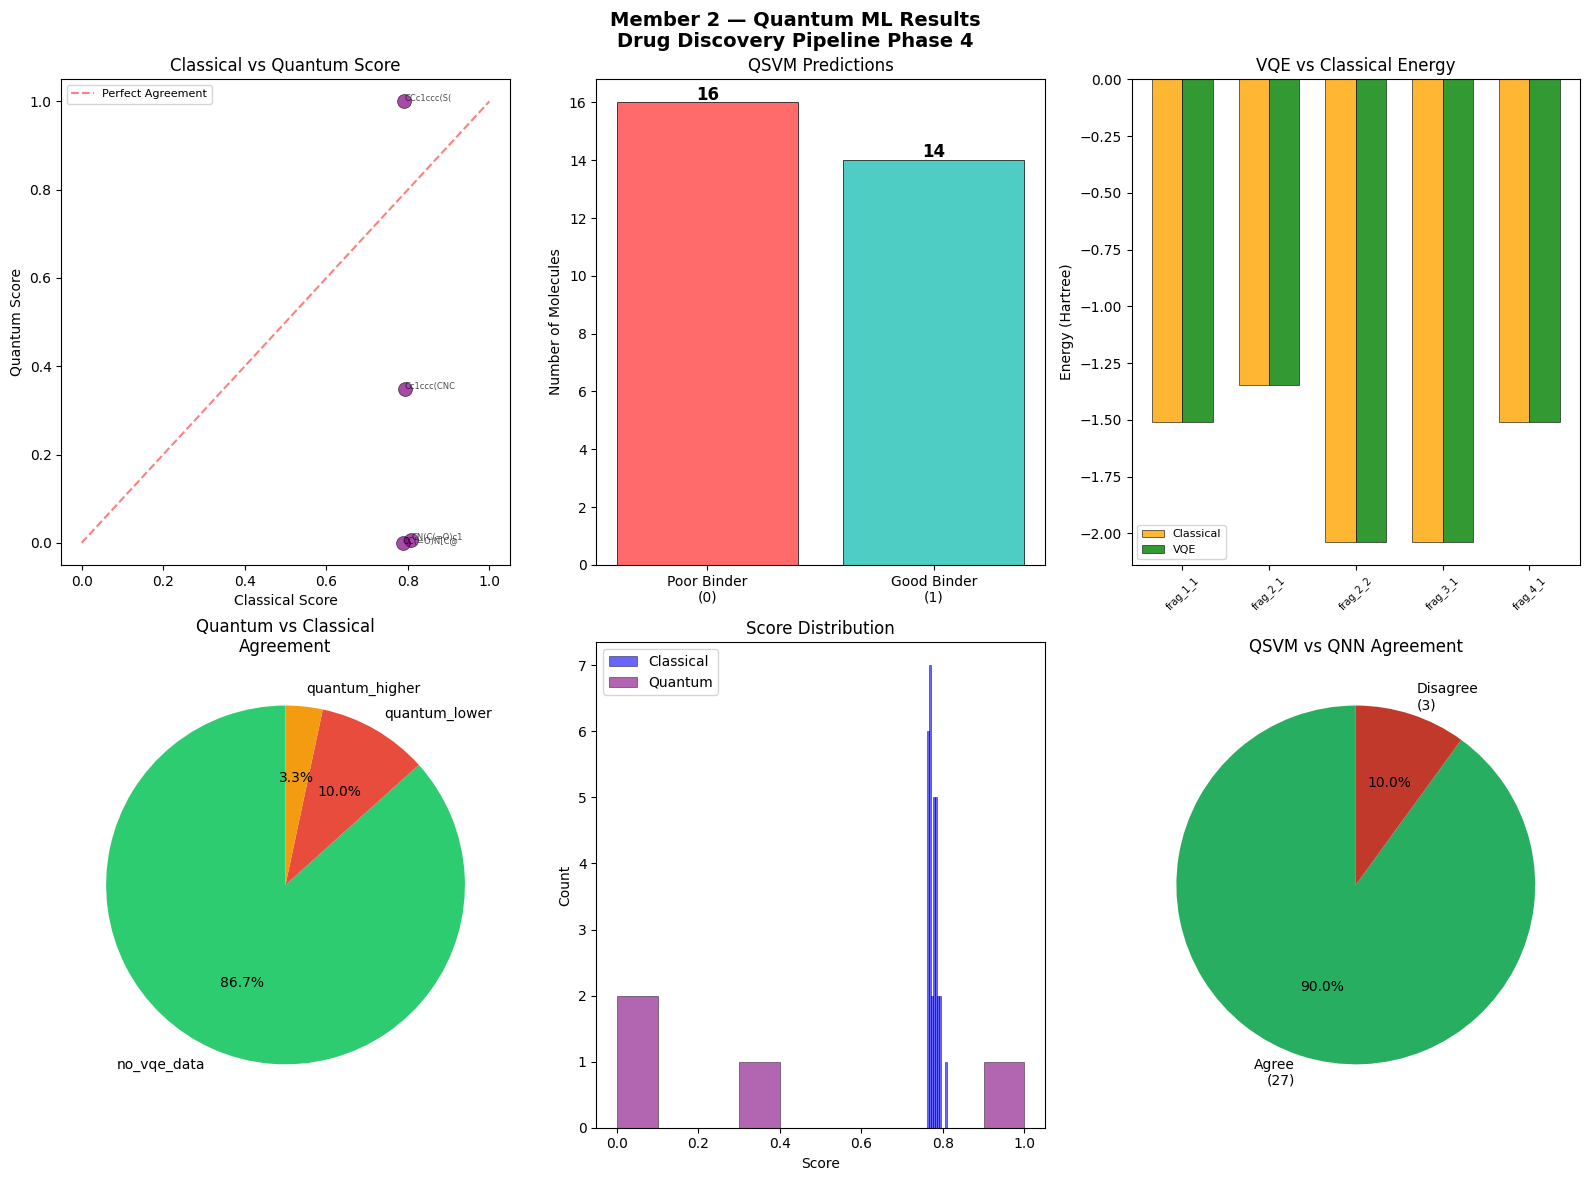

SAVED quantum_ml_results.png
DONE - Plots Complete!


In [ ]:
# CELL 10 — Visualize Results

print("="*45)
print("STEP 10 - Creating Plots")
print("="*45)

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle(
    'Member 2 — Quantum ML Results\n'
    'Drug Discovery Pipeline Phase 4',
    fontsize=14, fontweight='bold'
)

# ── Plot 1: Classical vs Quantum Score ──
ax1  = fig.add_subplot(gs[0, 0])
mask = df_compare['quantum_score'].notna()
if mask.sum() > 0:
    ax1.scatter(
        df_compare.loc[mask, 'classical_score'],
        df_compare.loc[mask, 'quantum_score'],
        c='purple', s=100, alpha=0.7,
        edgecolors='black', linewidths=0.5
    )
    # Annotate each point
    for _, row in df_compare[mask].iterrows():
        ax1.annotate(
            row['smiles'][:10],
            (row['classical_score'],
             row['quantum_score']),
            fontsize=6, alpha=0.7
        )
ax1.plot([0,1],[0,1],'r--',
         alpha=0.5, label='Perfect Agreement')
ax1.set_xlabel('Classical Score')
ax1.set_ylabel('Quantum Score')
ax1.set_title('Classical vs Quantum Score')
ax1.legend(fontsize=8)

# ── Plot 2: QSVM Predictions ──
ax2        = fig.add_subplot(gs[0, 1])
qsvm_count = pd.Series(
    df_compare['qsvm_prediction']
).value_counts().sort_index()
bars = ax2.bar(
    ['Poor Binder\n(0)', 'Good Binder\n(1)'],
    [qsvm_count.get(0, 0), qsvm_count.get(1, 0)],
    color=['#FF6B6B', '#4ECDC4'],
    edgecolor='black', linewidth=0.5
)
for bar, cnt in zip(
    bars,
    [qsvm_count.get(0,0), qsvm_count.get(1,0)]
):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        str(cnt), ha='center',
        fontweight='bold', fontsize=12
    )
ax2.set_title('QSVM Predictions')
ax2.set_ylabel('Number of Molecules')

# ── Plot 3: VQE vs Classical Energy ──
ax3 = fig.add_subplot(gs[0, 2])
if len(df_vqe_ok) > 0:
    x      = range(len(df_vqe_ok))
    width  = 0.35
    bars1  = ax3.bar(
        [i - width/2 for i in x],
        df_vqe_ok['classical_energy'],
        width, color='orange',
        alpha=0.8, label='Classical',
        edgecolor='black', linewidth=0.5
    )
    bars2  = ax3.bar(
        [i + width/2 for i in x],
        df_vqe_ok['vqe_energy'],
        width, color='green',
        alpha=0.8, label='VQE',
        edgecolor='black', linewidth=0.5
    )
    ax3.set_xticks(list(x))
    ax3.set_xticklabels(
        df_vqe_ok['fragment_id'],
        rotation=45, fontsize=7
    )
    ax3.set_title('VQE vs Classical Energy')
    ax3.set_ylabel('Energy (Hartree)')
    ax3.legend(fontsize=8)

# ── Plot 4: Systematic Difference Pie ──
ax4          = fig.add_subplot(gs[1, 0])
agree_counts = df_compare['systematic_diff'].value_counts()
colors_pie   = [
    '#2ECC71', '#E74C3C',
    '#F39C12', '#95A5A6'
]
ax4.pie(
    agree_counts.values,
    labels=agree_counts.index,
    colors=colors_pie[:len(agree_counts)],
    autopct='%1.1f%%',
    startangle=90
)
ax4.set_title('Quantum vs Classical\nAgreement')

# ── Plot 5: Score Distribution ──
ax5  = fig.add_subplot(gs[1, 1])
ax5.hist(
    df_compare['classical_score'],
    bins=10, alpha=0.6,
    color='blue', label='Classical',
    edgecolor='black', linewidth=0.5
)
mask2 = df_compare['quantum_score'].notna()
if mask2.sum() > 0:
    ax5.hist(
        df_compare.loc[mask2, 'quantum_score'],
        bins=10, alpha=0.6,
        color='purple', label='Quantum',
        edgecolor='black', linewidth=0.5
    )
ax5.set_xlabel('Score')
ax5.set_ylabel('Count')
ax5.set_title('Score Distribution')
ax5.legend()

# ── Plot 6: QSVM vs QNN Agreement ──
ax6          = fig.add_subplot(gs[1, 2])
agree_qnn    = (
    df_compare['qsvm_prediction'] ==
    df_compare['qnn_prediction']
).sum()
disagree_qnn = len(df_compare) - agree_qnn
ax6.pie(
    [agree_qnn, disagree_qnn],
    labels=[
        f'Agree\n({agree_qnn})',
        f'Disagree\n({disagree_qnn})'
    ],
    colors=['#27AE60', '#C0392B'],
    autopct='%1.1f%%',
    startangle=90
)
ax6.set_title('QSVM vs QNN Agreement')

plt.tight_layout()
plt.savefig(
    'quantum_ml_results.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("SAVED quantum_ml_results.png")
print("DONE - Plots Complete!")

In [ ]:
# CELL 11 — Download All Output Files

from google.colab import files
import os

print("="*45)
print("STEP 11 - Downloading Output Files")
print("="*45)

# ── Check all files exist ──
output_files = [
    'quantum_scores.csv',
    'qsvm_results.csv',
    'vqe_results.json',
    'classical_vs_quantum.csv',
    'quantum_ml_results.png'
]

print("\nChecking files:")
all_good = True
for fname in output_files:
    if os.path.exists(fname):
        size = os.path.getsize(fname)
        print(f"  ✅  {fname} ({size} bytes)")
    else:
        print(f"  ❌  {fname} MISSING")
        all_good = False

print()
if all_good:
    print("All files ready! Downloading now...")
    print()
    for fname in output_files:
        files.download(fname)
        print(f"  Downloaded → {fname}")
    print()
    print("="*45)
    print("🎉 ALL DONE!")
    print("="*45)
    print()
    print("Files to post to your team:")
    print("  1. quantum_scores.csv")
    print("  2. qsvm_results.csv")
    print("  3. vqe_results.json")
    print("  4. classical_vs_quantum.csv")
    print("  5. quantum_ml_results.png")
    print()
    print("Member 2 Phase 4 Complete! ✅")
else:
    print("⚠️ Some files missing!")
    print("Go back and rerun missing cells")

STEP 11 - Downloading Output Files

Checking files:
  ✅  quantum_scores.csv (547 bytes)
  ✅  qsvm_results.csv (4313 bytes)
  ✅  vqe_results.json (1982 bytes)
  ✅  classical_vs_quantum.csv (5875 bytes)
  ✅  quantum_ml_results.png (226597 bytes)

All files ready! Downloading now...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded → quantum_scores.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloaded → classical_vs_quantum.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded → quantum_ml_results.png

🎉 ALL DONE!

Files to post to your team:
  1. quantum_scores.csv
  2. qsvm_results.csv
  3. vqe_results.json
  4. classical_vs_quantum.csv
  5. quantum_ml_results.png

Member 2 Phase 4 Complete! ✅


In [ ]:
import pandas as pd

df_qs = pd.read_csv('quantum_scores.csv')

# Fill NaN with default value
df_qs['optimizer_evals'] = df_qs[
    'optimizer_evals'
].fillna(200)

df_qs.to_csv('quantum_scores.csv', index=False)
print("✅ Fixed! optimizer_evals filled with 200")
print(df_qs.to_string())

✅ Fixed! optimizer_evals filled with 200
  fragment_id              fragment  vqe_energy  classical_energy  energy_error  converged  optimizer_evals
0    frag_1_1  c1ccc(S(N)(=O)=O)cc1   -1.510940         -1.510940  1.696769e-07       True            200.0
1    frag_2_1             Cc1ccc(CN   -1.347857         -1.347857  6.179563e-08       True            200.0
2    frag_2_2         C2CCCC2CN)nc1   -2.036748         -2.036748  7.697516e-09       True            200.0
3    frag_3_1  CCc1ccc(S(=O)(=O)N2C   -2.036695         -2.036695  2.365138e-07       True            200.0
4    frag_4_1              N[C@H](C   -1.507784         -1.507784  1.843304e-08       True            200.0
